In [83]:
import mplhep
mplhep.style.use('ROOT')

import matplotlib.pyplot as plt
import hist
import uproot

class HistFile:
    def __init__(self, fp, ana, **kwargs):
        self._file = uproot.open(fp, **kwargs)
        self._ana = ana
        self._ana_dir = self._file[self._ana]

    def keys(self):
        return [
            key.removeprefix(f'{self._ana}_').removesuffix(';1')
            for key in self._ana_dir.keys()
        ]

    def __getitem__(self, item):
        if item in self._ana_dir:
            return self._ana_dir[item]
        if item in self._file:
            return self._file[item]
        return self._ana_dir[f'{self._ana}_{item}']

In [84]:
f = HistFile('hist_track_ana_1.root', 'TrackAnalyzer')

In [85]:
f.keys()

['event_tracks',
 'n_hits',
 'impact_point',
 'reco_momentum',
 'sim_momentum',
 'reco_leadtrk_momentum',
 'reco_vs_sim_momentum',
 'reco_vs_sim_momentum_nhits_10',
 'reco_vs_sim_momentum_nhits_under_10',
 'reco_vs_sim_momentum_under_4']

90.0 3.5199999999999996
70.0 6.41


Text(0, 1, 'Fraction Above')

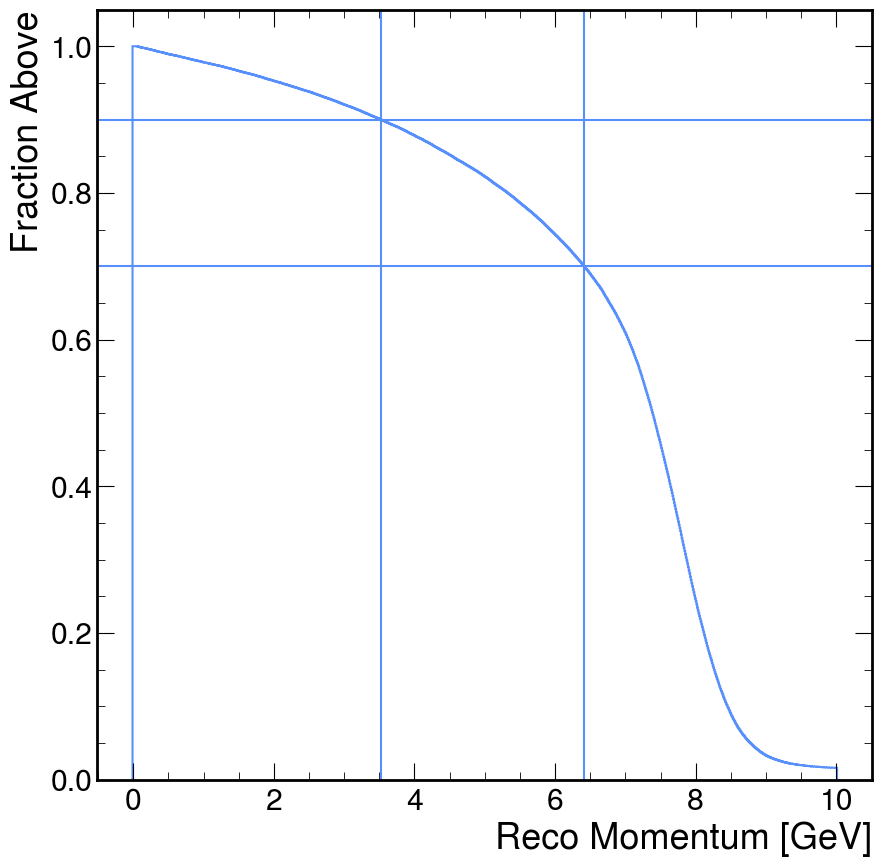

In [86]:
h = f['reco_leadtrk_momentum'].to_hist()
import numpy as np

fraction_above = np.flip(np.cumsum(np.flip(h.values(flow=True))))/np.sum(h.values(flow=True))
momentum = np.concatenate(([h.axes[0].edges[0]-0.01],h.axes[0].edges,[h.axes[0].edges[-1]+0.01]))

mplhep.histplot(fraction_above, bins = momentum)

for thresh in (0.9, 0.7):
    first_above = momentum[np.argmin(fraction_above>thresh)]
    print(100*thresh, first_above)
    # plt.annotate(f'(90%, {first_above:.2f} GeV)', (0.9,first_above), va='bottom', ha='left')
    plt.axvline(first_above)
    plt.axhline(thresh)

plt.xlabel('Reco Momentum [GeV]')
plt.ylabel('Fraction Above')

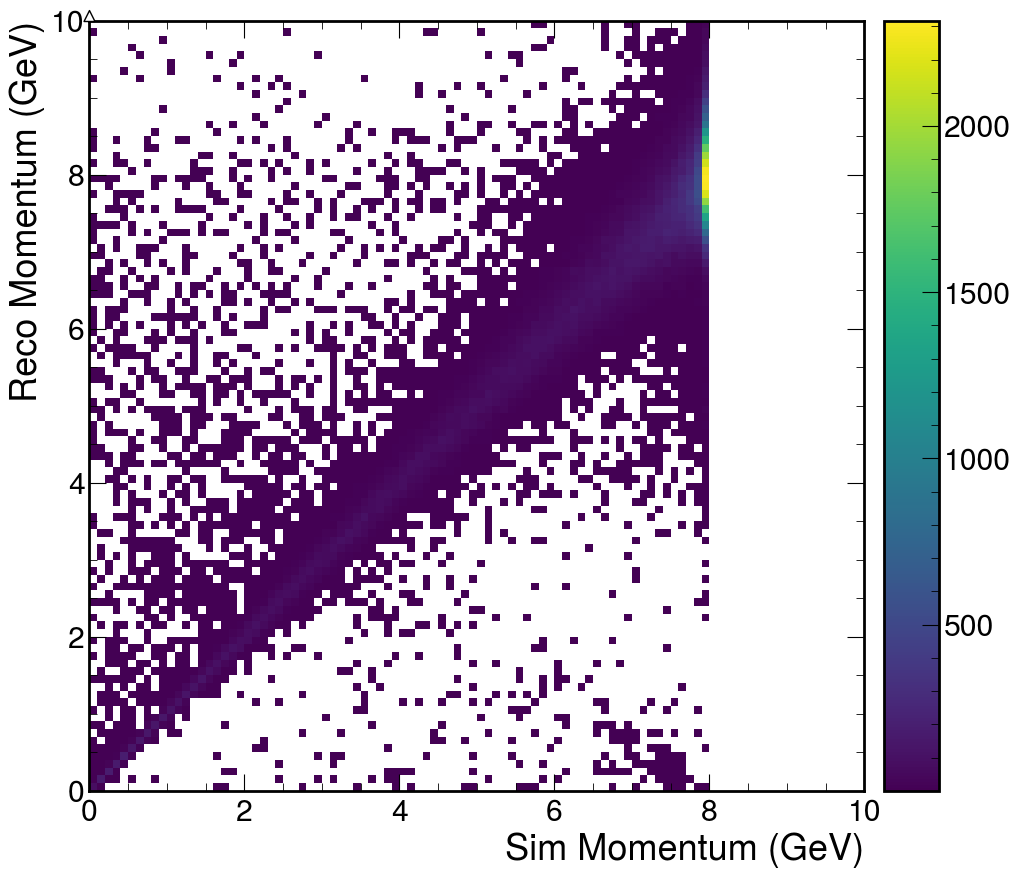

In [82]:
f['reco_vs_sim_momentum'].to_hist().plot(cmin=1)

plt.savefig("Reco_vs_Sim_Momentum.jpg")

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7feb741543e0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

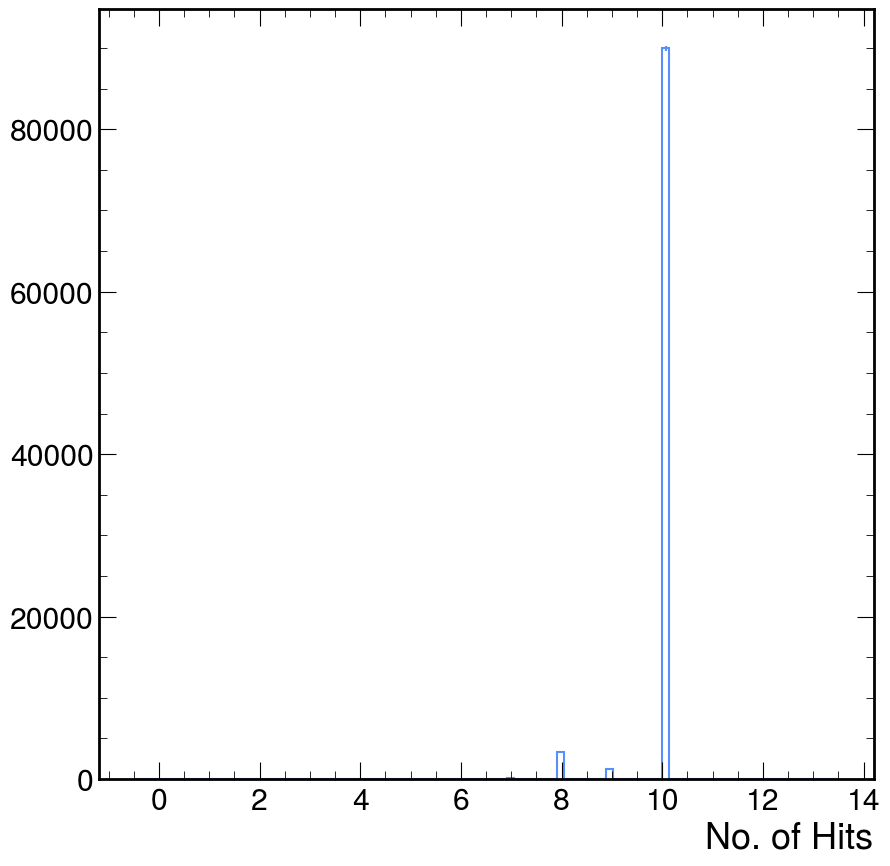

In [88]:

f['n_hits'].to_hist().plot()